In [1]:
import torch
import torch.nn as nn

In [239]:
class VAEEncoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_latent):
        super().__init__()
        self.n_latent = n_latent
        self.l1 = nn.Linear(n_in, n_hidden)
        self.mean = nn.Linear(n_hidden, n_latent)
        self.log_var = nn.Linear(n_hidden, n_latent)
        self.act = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        x = self.act(self.l1(x))
        mean = self.mean(x)
        log_var = self.log_var(x)
        z = mean + log_var.exp().sqrt() * torch.randn(self.n_latent)
        return z, mean, log_var

class VAEDecoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.n_in = n_in
        self.l1 = nn.Linear(n_in, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_hidden)
        self.l3 = nn.Linear(n_hidden, n_out)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, z):
        assert z.size(-1) == self.n_in
        z = self.act(self.l1(z))
        z = self.act(self.l2(z))
        z = torch.sigmoid(self.l3(z))
        return z

class VAE(nn.Module):
    def __init__(self, n_in, n_out, n_hidden, n_latent):
        super().__init__()
        self.n_in = n_in
        self.encode = VAEEncoder(n_in=n_in, n_hidden=n_hidden, n_latent=n_latent)
        self.decode = VAEDecoder(n_in=n_latent, n_hidden=n_hidden, n_out=n_out)
        
    def forward(self, x):
        assert x.size(-1) == self.n_in
        z, mean, logvar = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [240]:
model = VAE(n_in=784, n_out=784, n_hidden=500, n_latent=10)
model

VAE(
  (encode): VAEEncoder(
    (l1): Linear(in_features=784, out_features=500, bias=True)
    (mean): Linear(in_features=500, out_features=10, bias=True)
    (log_var): Linear(in_features=500, out_features=10, bias=True)
    (act): LeakyReLU(negative_slope=0.2)
  )
  (decode): VAEDecoder(
    (l1): Linear(in_features=10, out_features=500, bias=True)
    (l2): Linear(in_features=500, out_features=500, bias=True)
    (l3): Linear(in_features=500, out_features=784, bias=True)
    (act): LeakyReLU(negative_slope=0.2)
  )
)

In [5]:
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor, Lambda
import os

In [6]:
from torch.optim import AdamW

In [7]:
PATH = os.getcwd()

flatten = Lambda(lambda x: x.view(-1))

transform = Compose([
    ToTensor(),
    flatten
])

mnist_train = MNIST(root=PATH, download=True, train=True, transform=transform)
mnist_test = MNIST(root=PATH, download=True, train=False, transform=transform)
train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=100, shuffle=True)

In [8]:
import torch.nn.functional as F

In [209]:
def vae_loss_function(x_hat, x, mean, logvar):
    recon_term = F.binary_cross_entropy(x_hat, x, reduction='sum') # *negative* log-likelihood
    KL_term = - 0.5 * (1+logvar-mean.pow(2)-logvar.exp()).sum() # *negative* KL term
    return recon_term + KL_term # negative of function, cuz we minimize, not maximize

In [329]:
model = VAE(n_in=784, n_out=784, n_hidden=400, n_latent=10)
opt = AdamW(model.parameters(), lr=1e-3)
model.train()
#torch.manual_seed(42)
N_EPOCHS=10

for _ in range(N_EPOCHS):
    for i, [imgs, _] in enumerate(train_dataloader):
        opt.zero_grad()
        
        x_hat, mean, logvar = model(imgs)
        loss = vae_loss_function(x_hat, imgs, mean, logvar)
        loss.backward()
        opt.step()
        if i % 10 == 0: print(f"{i+1}: {loss.item()/100}")

1: 544.4868359375
11: 299.840390625
21: 235.796484375
31: 227.22052734375
41: 231.1944140625
51: 213.2273828125
61: 201.879921875
71: 205.81814453125
81: 195.9091796875
91: 194.202109375
101: 196.183125
111: 198.74998046875
121: 196.47837890625
131: 192.05384765625
141: 188.66412109375
151: 184.53849609375
161: 189.96900390625
171: 182.327578125
181: 193.7169921875
191: 175.19759765625
201: 182.5616796875
211: 162.89263671875
221: 180.068828125
231: 172.30248046875
241: 159.518876953125
251: 175.58783203125
261: 164.01513671875
271: 164.17765625
281: 159.956396484375
291: 152.972529296875
301: 174.8520703125
311: 162.99751953125
321: 156.68197265625
331: 155.32626953125
341: 144.5951953125
351: 147.350263671875
361: 143.856689453125
371: 150.077021484375
381: 166.4987109375
391: 144.927646484375
401: 146.62037109375
411: 147.1248046875
421: 156.741015625
431: 152.58759765625
441: 145.8455078125
451: 143.740029296875
461: 137.1483203125
471: 146.93236328125
481: 138.13216796875
491: 138

In [211]:
from matplotlib.pyplot import imshow

tensor([-1.8056,  1.4294,  1.7855, -0.9093,  0.1125,  0.5534,  0.6886, -1.1227,
        -0.5270, -1.6171])


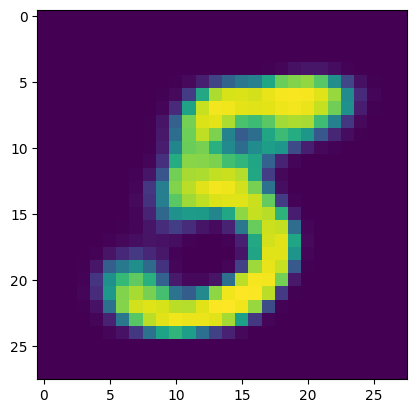

In [334]:
model.eval()
a = torch.randn(10)
print(a)
img = model.decode(a)
imshow(img.detach().numpy().reshape((28, 28)))

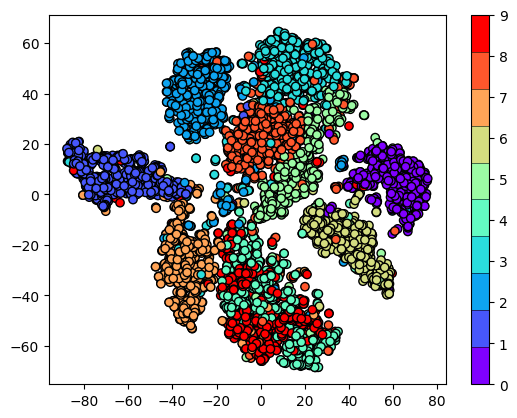

In [335]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

n_predict = 5_000
x_encoded_TSNE = TSNE().fit_transform(model(mnist_test.data[:n_predict].view(n_predict, -1)/255)[0].detach().numpy())

cmap = plt.get_cmap('rainbow', 10)
plt.scatter(x_encoded_TSNE[:,0], x_encoded_TSNE[:,1], 
                c=mnist_test.targets[:n_predict], edgecolor='black', cmap=cmap)
plt.colorbar(drawedges=True)
plt.show()